--- 1. LOADING DATA ---
Loaded 116471 lenses from LSST Y10.

--- 2. RUNNING PAIRING MC ---


MC Realizations: 100%|██████████| 20/20 [00:11<00:00,  1.81it/s]



--- 3. EXTRACTING SCATTER MODEL ---


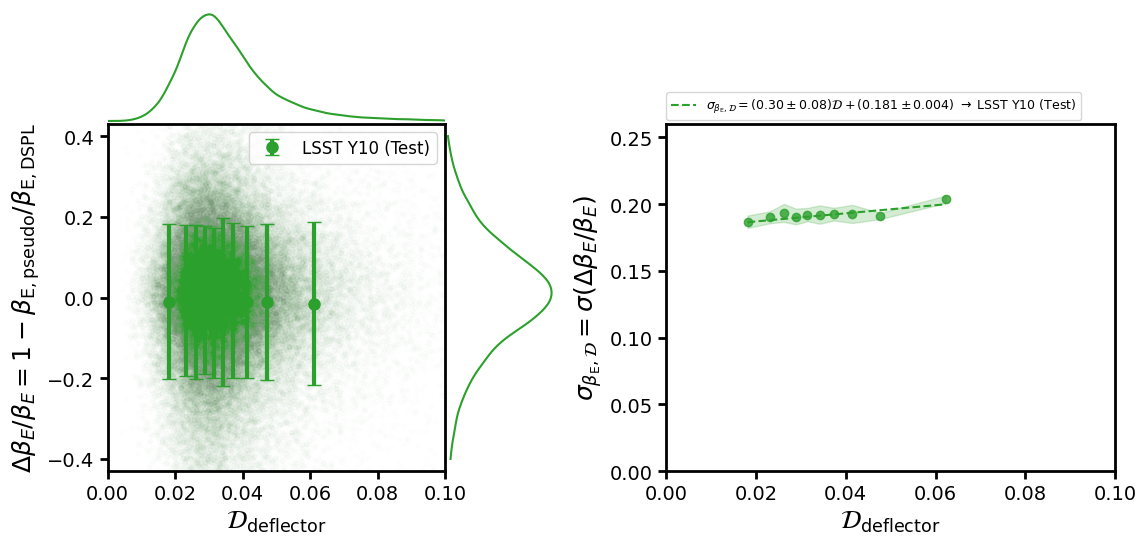

Extracted Linear Fit -> Intercept (c0): 0.1809 | Slope (c1): 0.3039


In [1]:
# =============================================================================
# END-TO-END PDSPL TEST: PAIRING & FORECASTING (LSST Y10)
# Uses real FITS data, Linear Scatter Fit, and Fixed-Scatter Inference.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM

# Import your pipeline utilities
from pdspl_utils.data_utils import preprocess_ggl_table
from pdspl_utils.pairing import (
    inject_observational_errors, get_kdtree_pairs, get_pairs_table_PDSPL,
    compute_dissimilarity, plot_beta_E_vs_D_MC, eval_scatter_model
)
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.plotting import plot_dspl_corner

import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
print("--- 1. LOADING DATA ---")
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

# Load the real LSST Y10 Catalog
catalog_path = "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
GGL_Y10 = preprocess_ggl_table(catalog_path)
print(f"Loaded {len(GGL_Y10)} lenses from LSST Y10.")

# Configuration dictionary for pairing
s = {
    "table": GGL_Y10,
    "name": "LSST Y10 (Test)",
    "color": "tab:green",
    "pairing_keys": ["z_D", "R_e_arcsec", "flux_D_i", "flux_ratio_D_gr", "flux_ratio_D_ri"],
    "dissimilarity_keys": ["rel_diff_z_D", "rel_diff_R_e_arcsec", "rel_diff_flux_D_i", 
                           "rel_diff_flux_ratio_D_gr", "rel_diff_flux_ratio_D_ri"],
    "error_config": {
        "sigma_v_D": 10.0,
        "R_e_arcsec": lambda t: 0.05 * t["R_e_arcsec"],
        "flux_D_i": lambda t: 0.01 * t["flux_D_i"],
        "flux_ratio_D_gr": lambda t: 0.014 * t["flux_ratio_D_gr"],
        "flux_ratio_D_ri": lambda t: 0.014 * t["flux_ratio_D_ri"],
        "z_D": lambda t: 0.03 * (1 + t["z_D"])  # LSST photo-z
    }
}
pdspl_samples = {"lsst_y10": s}

# =============================================================================
# 2. PAIRING STAGE (Monte Carlo Error Injection)
# =============================================================================
print("\n--- 2. RUNNING PAIRING MC ---")
N_realizations = 20  # <-- TEST VALUE: Increase to 100-500 for production
MAX_DISSIMILARITY = 0.15

mc_results = {"lsst_y10": {"binned_dissim": [], "binned_scatter": [], "num_pairs": [], "scatter_in_beta_E": []}}

for _ in tqdm(range(N_realizations), desc="MC Realizations"):
    # Inject errors, build tree, and create PDSPL pairs tables
    te = inject_observational_errors(s["table"], s["error_config"])
    idx, _ = get_kdtree_pairs(te, s["pairing_keys"], use_log_metric=True)
    
    pt = get_pairs_table_PDSPL(s["table"], idx, cosmo_true)
    pte = get_pairs_table_PDSPL(te, idx, cosmo_true)
    
    # Calculate RMS dissimilarity
    pte["dissimilarity"] = compute_dissimilarity(pte, s["dissimilarity_keys"], method="rms")
    
    # Store single realization (overwrites until the last one)
    s["pairs_analysis"] = {
        "pairs_table": pt, "pairs_table_with_errors": pte,
        "num_lenses": len(s["table"]), "num_pairs": len(pt),
        "scatter_in_beta_E": np.std(pt["rel_diff_beta_E"]), "pair_indices": idx,
    }
    
    mc_results["lsst_y10"]["num_pairs"].append(len(pt))
    mc_results["lsst_y10"]["scatter_in_beta_E"].append(np.std(pt["rel_diff_beta_E"]))
    
    # Binning for the scatter fit
    mask = (pte["dissimilarity"] < MAX_DISSIMILARITY) & np.isfinite(pt["rel_diff_beta_E"])
    dm, rm = pte["dissimilarity"][mask], pt["rel_diff_beta_E"][mask]
    pcts = np.percentile(dm, np.arange(0, 101, 10))
    dig = np.digitize(dm, pcts)
    
    rd, rs = [], []
    for i in range(1, len(pcts)):
        bm = dig == i
        rd.append(np.median(dm[bm]) if np.any(bm) else np.nan)
        rs.append(np.nanstd(rm[bm]) if np.any(bm) else np.nan)
        
    mc_results["lsst_y10"]["binned_dissim"].append(rd)
    mc_results["lsst_y10"]["binned_scatter"].append(rs)

# =============================================================================
# 3. FIT EXTRACTION & PLOTTING
# =============================================================================
print("\n--- 3. EXTRACTING SCATTER MODEL ---")
# Explicitly use the 'linear' fit to map to c0 (intercept) and c1 (slope)
fig_pairing = plot_beta_E_vs_D_MC(
    pdspl_samples, mc_results, 
    fit_type="linear", 
    show_fit_eqn_label=True
)
plt.show()

# Extract the calibrated linear fit coefficients
pa = s["pairs_analysis"]
coeffs = pa["scatter_vs_dissimilarity_fit_coeffs"]
c1_slope, c0_intercept = coeffs[0], coeffs[1]

print(f"Extracted Linear Fit -> Intercept (c0): {c0_intercept:.4f} | Slope (c1): {c1_slope:.4f}")


--- 4. GENERATING MOCK FORECAST DATA ---
Generated 2000 Asimov mock systems.

--- 5. RUNNING MCMC INFERENCE ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 7000/7000 [14:18<00:00,  8.15it/s]



--- 6. PLOTTING FINAL FORECAST ---


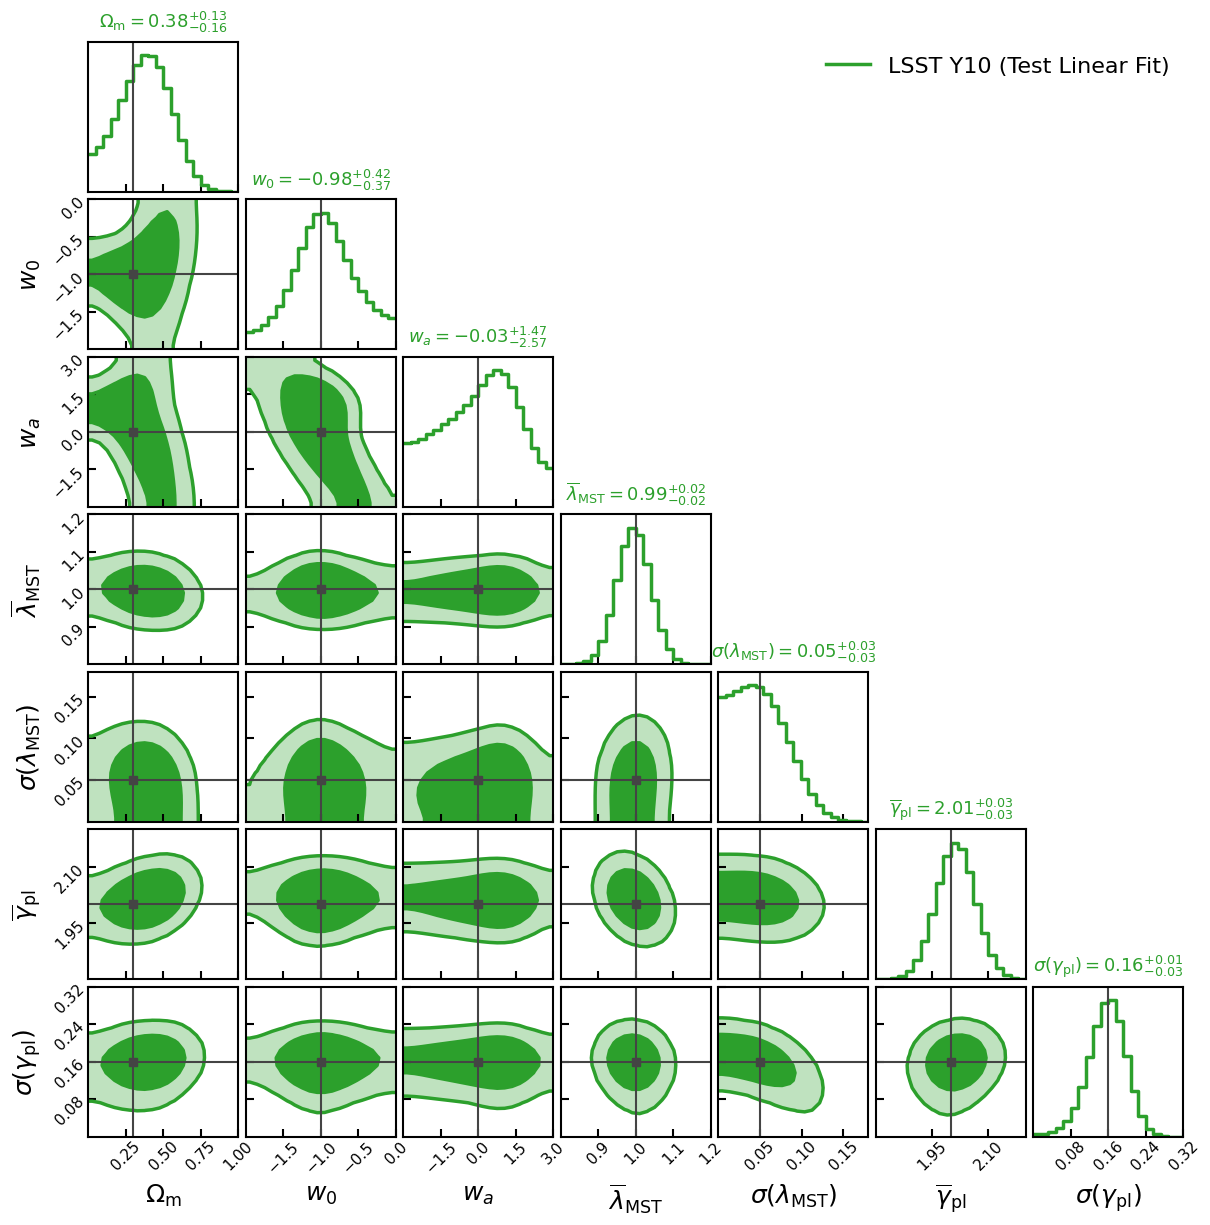


--- TEST COMPLETE ---


In [7]:
# =============================================================================
# 4. FORECASTING STAGE (Generating Mock DSPL Data)
# =============================================================================
print("\n--- 4. GENERATING MOCK FORECAST DATA ---")
truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int": 1.0, "lambda_sigma": 0.05,
    "gamma_pl": 2.0, "gamma_sigma": 0.16,
}
cosmo_true_w = Flatw0waCDM(H0=truth["h0"], Om0=truth["om"], w0=truth["w0"], wa=truth["wa"])

down_sampling = len(pa["pairs_table"]) / 2000
num_samples = int(len(pa["pairs_table"]) / down_sampling)
random_indices = np.random.choice(len(pa["pairs_table"]), size=num_samples, replace=False)

# random_indices = range(len(pa["pairs_table"]))  # use all pairs for the Asimov mock (no down-sampling)
# down_sampling = 1

kwargs_list = []
for i in random_indices:
    z_lens = pa["pairs_table"]["z_D"][i]
    z1 = pa["pairs_table"]["z_S1"][i]
    z2 = pa["pairs_table"]["z_S2"][i]
    dissimilarity = pa["pairs_table_with_errors"]["dissimilarity"][i]

    # Evaluate using the proper eval function to ensure mathematical consistency
    sigma_beta_intrinsic = eval_scatter_model(coeffs, "linear", dissimilarity)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
        gamma_pl_mean=truth["gamma_pl"], gamma_pl_sigma=truth["gamma_sigma"],
        sigma_beta_intrinsic=sigma_beta_intrinsic,
        sigma_meas_rel=np.sqrt(0.01**2 + 0.01**2),
        dissimilarity=dissimilarity,
        down_sampling=down_sampling,
        with_noise=False, # Asimov mock for forecasting
        cosmo=cosmo_true_w,
        redshift_error_rel=0.03,
    ))

print(f"Generated {len(kwargs_list)} Asimov mock systems.")

# =============================================================================
# 5. MCMC INFERENCE (Fixed Scatter)
# =============================================================================
print("\n--- 5. RUNNING MCMC INFERENCE ---")

# Pass extracted linear coefficients securely as fixed parameters
fixed_params_sc = {
    "h0": 70.0, 
    "beta_c0": c0_intercept, 
    "beta_c1": c1_slope, 
    "beta_c2": 0.0
}

my_guess = {"om": 0.3, "w0": -1.0, "wa": 0.0, "lambda_int": 1.0, "lambda_sigma": 0.05, "gamma_pl": 2.0, "gamma_sigma": 0.16}
my_spreads = {"om": 0.1, "w0": 0.1, "wa": 0.1, "lambda_int": 0.1, "lambda_sigma": 0.01, "gamma_pl": 0.1, "gamma_sigma": 0.01}
my_priors = {
    "h0":           ("uniform", 50.0, 90.0),
    "om":           ("uniform",  0.0,  1.0),
    "w0":           ("uniform", -3.0,  0.0),
    "wa":           ("uniform", -5.0,  5.0),
    "lambda_int":   ("uniform",  0.8,  1.2),
    "lambda_sigma": ("uniform",  0.0,  0.2),
    "gamma_pl":     ("uniform",  1.0,  3.0),
    "gamma_sigma":  ("uniform",  0.0,  0.5),
}

# Note: Using lower walkers and steps for this quick test script
samples, labels = run_dspl_inference(
    kwargs_list,
    n_walkers=64, n_steps=7000, n_burn=1000,  # <-- TEST VALUES: Bump to 64/2000/500 for production
    initial_guess=my_guess,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors,
    scatter_model_type="linear"  # <-- CRITICAL: Forces Likelihood to use linear model
)

# =============================================================================
# 6. RESULTS & CORNER PLOT
# =============================================================================
print("\n--- 6. PLOTTING FINAL FORECAST ---")
scenario_dict = {
    "lsst_y10_test": {
        "name": "LSST Y10 (Test Linear Fit)",
        "samples": samples,
        "color": "tab:green"
    }
}

latex_labels = {
    "om": r"$\Omega_{\rm m}$", "w0": r"$w_0$", "wa": r"$w_a$",
    "lambda_int": r"$\overline{\lambda}_{\rm MST}$", "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
    "gamma_pl": r"$\overline{\gamma}_{\rm pl}$", "gamma_sigma": r"$\sigma({\gamma}_{\rm pl})$",
}
custom_ranges = [(0, 1), (-2, 0), (-3, 3), (0.8, 1.2), (0.0, 0.18), (1.8, 2.2), (0.0, 0.32)]

fig_forecast = plot_dspl_corner(
    scenarios=scenario_dict, truth=truth, fixed_params=fixed_params_sc,
    scenarios_to_plot=["lsst_y10_test"],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(12, 12),
    show_multiple_titles=True
)
plt.show()

print("\n--- TEST COMPLETE ---")

--- RUNNING CONVERGENCE DIAGNOSTICS ---


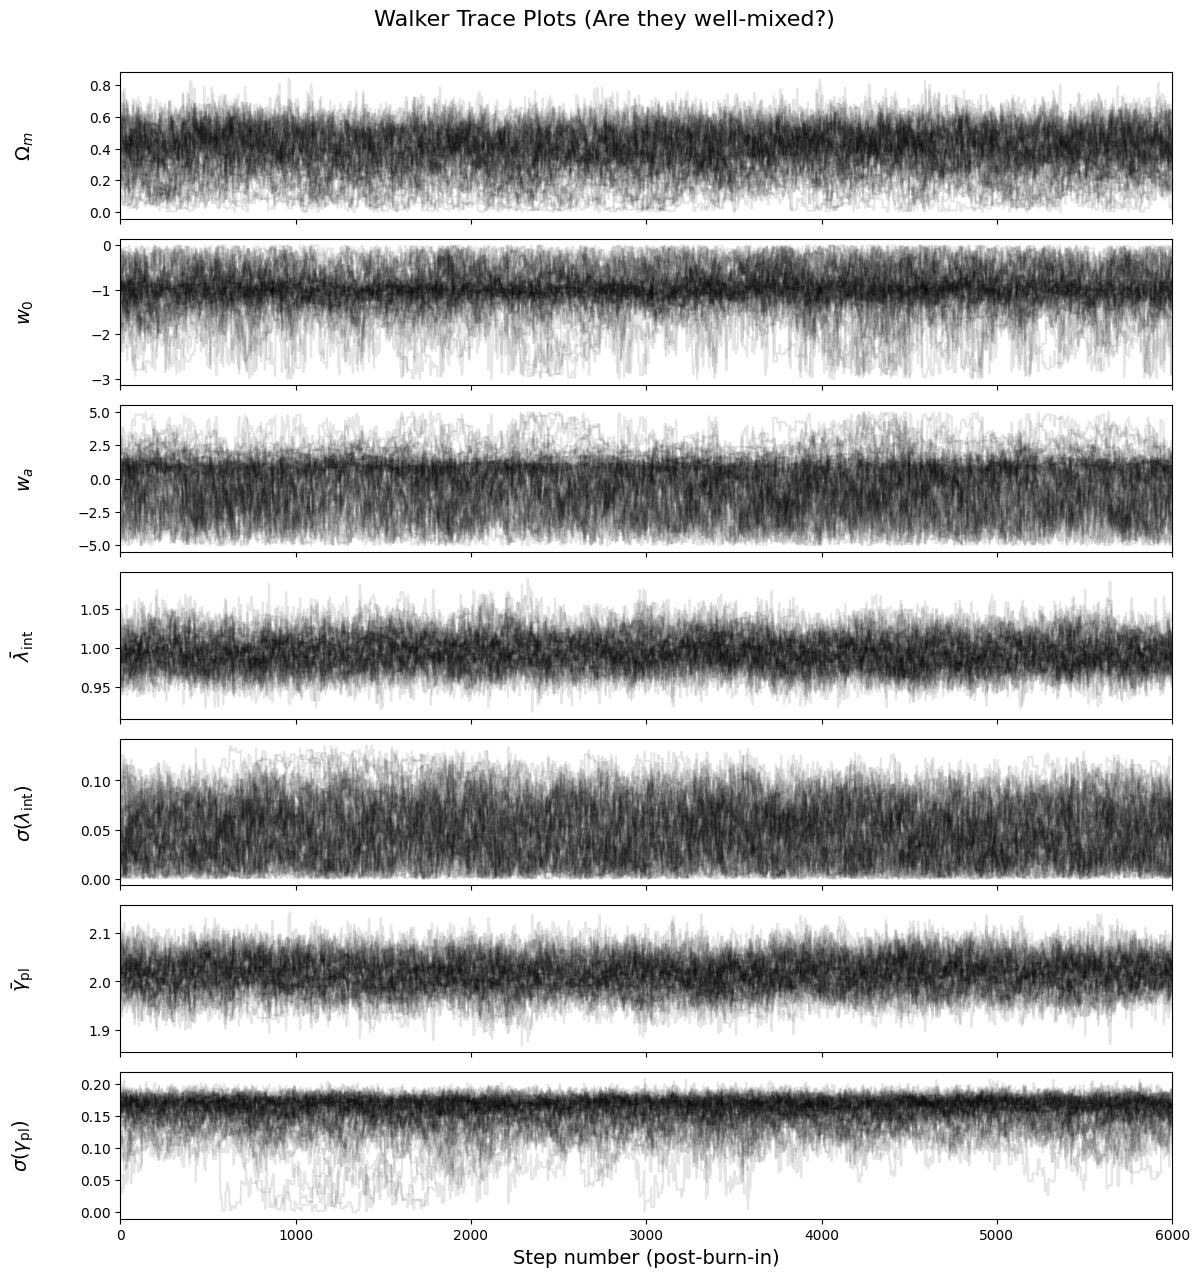


--- AUTOCORRELATION TIME (tau) ---
Rule of thumb: To be converged, your total steps should be > 50 * tau.
Parameter                 | tau (steps)     | Min Required Steps  
-----------------------------------------------------------------
Omega_m                   | 195.3           | 9767                
w_0                       | 177.3           | 8865                
w_a                       | 219.1           | 10957               
barlambda_int             | 133.5           | 6676                
sigma(lambda_int)         | 189.0           | 9450                
bargamma_pl               | 134.8           | 6739                
sigma(gamma_pl)           | 185.4           | 9269                

! WARNING: Chain is too short. You have 6000 post-burn-in steps, but need at least 10957 for full convergence.


In [8]:
# =============================================================================
# MCMC CONVERGENCE DIAGNOSTICS
# =============================================================================
import emcee
import numpy as np
import matplotlib.pyplot as plt

print("--- RUNNING CONVERGENCE DIAGNOSTICS ---")

# 1. Unflatten the chain
# Replace 64 with 32 if you ran the quick test version!
n_walkers = 64  
ndim = samples.shape[1]
n_steps_kept = samples.shape[0] // n_walkers

# emcee flattens chains by stacking walkers, so we just reshape it back
chain = samples.reshape((n_steps_kept, n_walkers, ndim))

# 2. Visual Check: Trace Plots
fig, axes = plt.subplots(ndim, figsize=(12, 1.8 * ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    # Plot all walkers for this parameter with low opacity
    ax.plot(chain[:, :, i], "k", alpha=0.1)
    ax.set_xlim(0, n_steps_kept)
    ax.set_ylabel(labels[i], fontsize=14)
    ax.yaxis.set_label_coords(-0.08, 0.5)

axes[-1].set_xlabel("Step number (post-burn-in)", fontsize=14)
fig.suptitle("Walker Trace Plots (Are they well-mixed?)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# 3. Quantitative Check: Autocorrelation Time (tau)
print("\n--- AUTOCORRELATION TIME (tau) ---")
print("Rule of thumb: To be converged, your total steps should be > 50 * tau.")

try:
    # tol=0 forces emcee to give us an estimate even if the chain is short/unconverged
    tau = emcee.autocorr.integrated_time(chain, tol=0) 
    
    print(f"{'Parameter':<25} | {'tau (steps)':<15} | {'Min Required Steps':<20}")
    print("-" * 65)
    for i, label in enumerate(labels):
        # Strip out the LaTeX math formatting for the print statement
        clean_label = label.replace('$', '').replace('\\', '').replace('rm ', '').replace('{', '').replace('}', '')
        min_steps = int(50 * tau[i])
        print(f"{clean_label:<25} | {tau[i]:<15.1f} | {min_steps:<20}")
        
    # Quick overall health check
    max_tau = np.max(tau)
    if n_steps_kept > 50 * max_tau:
        print(f"\n✓ HEALTHY: Your post-burn-in chain ({n_steps_kept} steps) is longer than 50x the max tau ({int(50*max_tau)} steps).")
    else:
        print(f"\n! WARNING: Chain is too short. You have {n_steps_kept} post-burn-in steps, but need at least {int(50*max_tau)} for full convergence.")
        
except Exception as e:
    print(f"Could not calculate autocorrelation time. The chain might be severely stuck or too short. Error: {e}")

In [6]:
# =============================================================================
# TIME PROFILING THE LIKELIHOOD BOTTLENECK
# =============================================================================
import cProfile
import pstats
import io

print("--- STARTING PROFILER (50 MCMC Steps) ---")

# Initialize the profiler
profiler = cProfile.Profile()
profiler.enable()

# Run a very short chain to capture the function call overhead
samples_prof, labels_prof = run_dspl_inference(
    kwargs_list,
    n_walkers=32, n_steps=50, n_burn=10,  # Kept extremely short for profiling
    initial_guess=my_guess,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors,
    scatter_model_type="linear",
)

profiler.disable()

# =============================================================================
# PRINT RESULTS
# =============================================================================
print("\n--- PROFILING RESULTS ---")

s = io.StringIO()
# 'tottime' sorts by the time spent strictly inside the function itself
# 'cumtime' sorts by the time spent in the function AND all its sub-functions
ps = pstats.Stats(profiler, stream=s).sort_stats('tottime')

# Print the top 30 most time-consuming functions
ps.print_stats(30)

print(s.getvalue())

--- STARTING PROFILER (50 MCMC Steps) ---


ValueError: Another profiling tool is already active

In [6]:
import time
import numpy as np

# Import Astropy
from astropy.cosmology import FlatLambdaCDM

# Safely try importing CCL
try:
    import pyccl as ccl
    HAS_CCL = True
except ImportError:
    HAS_CCL = False

# Safely try importing Colossus
try:
    from colossus.cosmology import cosmology as col_cosmo
    HAS_COLOSSUS = True
except ImportError:
    HAS_COLOSSUS = False

# =====================================================================
# 1. SETUP MOCK DATA
# =====================================================================
N_systems = 100000  # Number of lenses/sources evaluated per MCMC step
z_array = np.random.uniform(0.1, 3.0, N_systems)

# MCMC Step Parameters
h, om = 0.7, 0.3

print(f"--- TIMING COSMOLOGY ENGINES ({N_systems:,} redshifts per step) ---\n")

# =====================================================================
# TEST 1: Pure Astropy (Your Current Bottleneck)
# =====================================================================
t0 = time.time()

# 1. Instantiate (Fast)
cosmo_astropy = FlatLambdaCDM(H0=h*100, Om0=om)
# 2. Evaluate (Slow: numerical integration for all 10,000 elements)
dist_astropy = cosmo_astropy.comoving_distance(z_array).value

t_astropy = time.time() - t0
print(f"1. Pure Astropy:                 {t_astropy:.4f} seconds")

# =====================================================================
# TEST 2: Astropy + Numpy 1D Interpolation (The Quick Fix)
# =====================================================================
t0 = time.time()

# 1. Instantiate
cosmo_astropy_interp = FlatLambdaCDM(H0=h*100, Om0=om)
# 2. Build small 500-point grid (500 integrals)
z_grid = np.linspace(0, 3.5, 500)
dist_grid = cosmo_astropy_interp.comoving_distance(z_grid).value
# 3. Interpolate for the 10,000 systems (Vectorized & Instant)
dist_interp = np.interp(z_array, z_grid, dist_grid)

t_interp = time.time() - t0
print(f"2. Astropy + 1D Interpolation:   {t_interp:.4f} seconds  [~{t_astropy/t_interp:.0f}x faster]")

# =====================================================================
# TEST 3: PyCCL (The DESC Standard)
# =====================================================================
if HAS_CCL:
    t0 = time.time()
    
    # 1. Instantiate (Builds C-level splines in the background)
    cosmo_ccl = ccl.Cosmology(Omega_c=om - 0.05, Omega_b=0.05, h=h, n_s=0.96, sigma8=0.8)
    # 2. Evaluate (CCL uses scale factor 'a' instead of redshift 'z')
    a_array = 1.0 / (1.0 + z_array)
    dist_ccl = ccl.comoving_radial_distance(cosmo_ccl, a_array)
    
    t_ccl = time.time() - t0
    print(f"3. PyCCL (C-backed Splines):     {t_ccl:.4f} seconds  [~{t_astropy/t_ccl:.0f}x faster]")
else:
    print("3. PyCCL:                        [Not Installed]")

# =====================================================================
# TEST 4: Colossus (Python Alternative)
# =====================================================================
if HAS_COLOSSUS:
    t0 = time.time()
    
    # 1. Instantiate (Builds Python-level splines)
    params = {'flat': True, 'H0': h*100, 'Om0': om, 'Ob0': 0.05, 'sigma8': 0.8, 'ns': 0.96}
    cosmo_col = col_cosmo.setCosmology('myCosmo', params)
    # 2. Evaluate (Instant table lookup)
    # Note: Colossus returns distances in Mpc/h, so we divide by h to match Astropy's Mpc
    dist_col = cosmo_col.comovingDistance(z_min=0.0, z_max=z_array) / h
    
    t_col = time.time() - t0
    print(f"4. Colossus (Python Splines):    {t_col:.4f} seconds  [~{t_astropy/t_col:.0f}x faster]")
else:
    print("4. Colossus:                     [Not Installed]")

--- TIMING COSMOLOGY ENGINES (100,000 redshifts per step) ---

1. Pure Astropy:                 0.0308 seconds
2. Astropy + 1D Interpolation:   0.0094 seconds  [~3x faster]
3. PyCCL (C-backed Splines):     0.0290 seconds  [~1x faster]
4. Colossus (Python Splines):    6.7193 seconds  [~0x faster]


In [9]:
import time
import numpy as np
from astropy.cosmology import Flatw0waCDM

try:
    import pyccl as ccl
    HAS_CCL = True
except ImportError:
    HAS_CCL = False

# =====================================================================
# 1. SETUP MOCK LENS SYSTEMS
# =====================================================================
N_systems = 100000  # Number of systems per MCMC step
# Enforce geometric reality: z_L < z_S1 < z_S2
z_l  = np.random.uniform(0.1, 0.8, N_systems)
z_s1 = z_l + np.random.uniform(0.1, 1.0, N_systems)
z_s2 = z_s1 + np.random.uniform(0.1, 1.5, N_systems)

# Target Cosmology with w0, wa
h, om, w0, wa = 0.7, 0.3, -1.0, 0.1

print(f"--- TIMING BETA EVALUATION ({N_systems:,} systems / Flatw0waCDM) ---\n")

# =====================================================================
# METHOD 1: Pure Astropy (Your Current MCMC Setup)
# =====================================================================
t0 = time.time()
cosmo_astropy = Flatw0waCDM(H0=h*100, Om0=om, w0=w0, wa=wa)

ds1  = cosmo_astropy.angular_diameter_distance(z_s1).value
ds2  = cosmo_astropy.angular_diameter_distance(z_s2).value
dds1 = cosmo_astropy.angular_diameter_distance_z1z2(z_l, z_s1).value
dds2 = cosmo_astropy.angular_diameter_distance_z1z2(z_l, z_s2).value

beta_astropy = (dds1 / ds1) * (ds2 / dds2)
t_astropy = time.time() - t0

print(f"1. Pure Astropy:                 {t_astropy:.4f} seconds")

# =====================================================================
# METHOD 2: Astropy + 1D Interpolation + Flat Universe Simplification
# =====================================================================
t0 = time.time()
cosmo_interp = Flatw0waCDM(H0=h*100, Om0=om, w0=w0, wa=wa)

# Evaluate exactly 1000 integrals
max_z = max(np.max(z_l), np.max(z_s1), np.max(z_s2))
z_grid = np.linspace(0.0, max_z + 0.1, 1000)
Dc_grid = cosmo_interp.comoving_distance(z_grid).value

# Interpolate & simplify
Dc_l  = np.interp(z_l,  z_grid, Dc_grid)
Dc_s1 = np.interp(z_s1, z_grid, Dc_grid)
Dc_s2 = np.interp(z_s2, z_grid, Dc_grid)
beta_interp = (1.0 - Dc_l / Dc_s1) / (1.0 - Dc_l / Dc_s2)
t_interp = time.time() - t0

print(f"2. Astropy + 1D Interpolation:   {t_interp:.4f} seconds  [~{t_astropy/t_interp:.0f}x faster]")

# =====================================================================
# METHOD 3: PyCCL (C-backed Splines)
# =====================================================================
if HAS_CCL:
    t0 = time.time()
    cosmo_ccl = ccl.Cosmology(Omega_c=om-0.05, Omega_b=0.05, h=h, w0=w0, wa=wa, n_s=0.96, sigma8=0.8)
    
    # CCL works natively in scale factor 'a'
    Dc_l  = ccl.comoving_radial_distance(cosmo_ccl, 1.0/(1.0+z_l))
    Dc_s1 = ccl.comoving_radial_distance(cosmo_ccl, 1.0/(1.0+z_s1))
    Dc_s2 = ccl.comoving_radial_distance(cosmo_ccl, 1.0/(1.0+z_s2))
    
    beta_ccl = (1.0 - Dc_l / Dc_s1) / (1.0 - Dc_l / Dc_s2)
    t_ccl = time.time() - t0
    
    print(f"3. PyCCL (C-backed Splines):     {t_ccl:.4f} seconds  [~{t_astropy/t_ccl:.0f}x faster]")
else:
    print("3. PyCCL:                        [Not Installed]")

# =====================================================================
# VERIFICATION CHECK
# =====================================================================
print("\n--- VERIFICATION ---")
err_interp = np.max(np.abs(beta_astropy - beta_interp))
print(f"Max difference (Astropy vs Interp): {err_interp:.2e}")

if HAS_CCL:
    err_ccl = np.max(np.abs(beta_astropy - beta_ccl))
    print(f"Max difference (Astropy vs CCL):    {err_ccl:.2e}")

--- TIMING BETA EVALUATION (100,000 systems / Flatw0waCDM) ---

1. Pure Astropy:                 1.3244 seconds
2. Astropy + 1D Interpolation:   0.0206 seconds  [~64x faster]
3. PyCCL (C-backed Splines):     0.0355 seconds  [~37x faster]

--- VERIFICATION ---
Max difference (Astropy vs Interp): 3.27e-06
Max difference (Astropy vs CCL):    9.67e-06


In [11]:
import time
import numpy as np
from astropy.cosmology import Flatw0waCDM

# =====================================================================
# 1. THE ORIGINAL (SLOW) FUNCTION
# =====================================================================
def original_beta_double_source_plane(z_lens, z_source_1, z_source_2, cosmo):
    z_lens     = np.atleast_1d(z_lens)
    z_source_1 = np.atleast_1d(z_source_1)
    z_source_2 = np.atleast_1d(z_source_2)

    ds1  = cosmo.angular_diameter_distance(z_source_1).value
    ds2  = cosmo.angular_diameter_distance(z_source_2).value
    dds1 = cosmo.angular_diameter_distance_z1z2(z_lens, z_source_1).value
    dds2 = cosmo.angular_diameter_distance_z1z2(z_lens, z_source_2).value

    return (dds1 / ds1) * (ds2 / dds2)

# =====================================================================
# 2. THE NEW GENERALIZED (FAST) FUNCTION
# =====================================================================
def fast_beta_double_source_plane(z_lens, z_source_1, z_source_2, cosmo, n_grid=1000):
    """
    Optimized geometric scaling factor β for a double source plane configuration.
    Uses 1D interpolation and flat-universe mathematical simplification.
    """
    z_lens     = np.atleast_1d(z_lens)
    z_source_1 = np.atleast_1d(z_source_1)
    z_source_2 = np.atleast_1d(z_source_2)

    # Safety Fallback: The simplified math only works if Omega_k = 0
    if not cosmo.is_flat:
        return original_beta_double_source_plane(z_lens, z_source_1, z_source_2, cosmo)

    # 1. Determine the maximum redshift to bound our interpolation grid
    max_z = np.max([np.max(z_lens), np.max(z_source_1), np.max(z_source_2)])

    # 2. Build the grid (evaluate Astropy integrals n_grid times instead of N_systems)
    z_grid = np.linspace(0.0, max_z + 0.1, n_grid)
    Dc_grid = cosmo.comoving_distance(z_grid).value

    # 3. Instantly interpolate the distances for all systems
    Dc_l  = np.interp(z_lens, z_grid, Dc_grid)
    Dc_s1 = np.interp(z_source_1, z_grid, Dc_grid)
    Dc_s2 = np.interp(z_source_2, z_grid, Dc_grid)

    # 4. Vectorized geometric scaling factor (Flat universe simplification)
    return (1.0 - Dc_l / Dc_s1) / (1.0 - Dc_l / Dc_s2)

# =====================================================================
# 3. TIME PROFILING & VERIFICATION
# =====================================================================
# Generate 12,000 realistic lens systems (mimicking your LSST Y10 mock)
N_systems = 12000
z_l  = np.random.uniform(0.1, 0.8, N_systems)
z_s1 = z_l + np.random.uniform(0.1, 1.0, N_systems)
z_s2 = z_s1 + np.random.uniform(0.1, 1.5, N_systems)

# Target Cosmology (Flatw0waCDM requires expensive numerical integration)
cosmo_test = Flatw0waCDM(H0=70.0, Om0=0.3, w0=-1.0, wa=0.0)

print(f"--- TIMING BETA EVALUATION ({N_systems:,} Systems) ---\n")

# Profile Original Method
t0 = time.time()
beta_old = original_beta_double_source_plane(z_l, z_s1, z_s2, cosmo_test)
t_old = time.time() - t0
print(f"1. Original Method (Pure Astropy):       {t_old:.4f} seconds")

# Profile Fast Method
t0 = time.time()
beta_fast = fast_beta_double_source_plane(z_l, z_s1, z_s2, cosmo_test)
t_fast = time.time() - t0
print(f"2. Fast Method (1D Grid Interpolation):  {t_fast:.4f} seconds")

# Speedup & Accuracy Check
speedup = t_old / t_fast
max_diff = np.max(np.abs(beta_old - beta_fast))

print(f"\n--- RESULTS ---")
print(f"Speedup multiplier:                      {speedup:.0f}x faster")
print(f"Maximum mathematical difference:         {max_diff:.2e}")

--- TIMING BETA EVALUATION (12,000 Systems) ---

1. Original Method (Pure Astropy):       0.1559 seconds
2. Fast Method (1D Grid Interpolation):  0.0048 seconds

--- RESULTS ---
Speedup multiplier:                      33x faster
Maximum mathematical difference:         3.25e-06
